<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science-Ml/blob/main/Data_Preprocessing_Assignment%5B10%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing and Feature Engineering in Machine Learning

**Dataset:** Adult Census Income dataset  
**Goal:** Prepare the data for machine learning by handling missing values, scaling numerical features, encoding categorical variables, creating useful features, and transforming a skewed numerical variable.

I have kept the workflow practical and used comments where a step is a little less obvious so that the reasoning behind the preprocessing is clear.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

# Load the supplied CSV file.
df = pd.read_csv("adult_with_headers (1).csv")

print("Shape:", df.shape)
df.head()


Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1. Basic data exploration

The dataset contains census-related information such as age, education, occupation, hours worked per week, and capital gains/losses. The target variable is `income`.


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics for numerical columns:")
display(df.describe().T)

print("\nSummary statistics including categorical columns:")
display(df.describe(include="all").T)


Number of rows: 32561
Number of columns: 15

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Summary statistics for numerical columns:


,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education_num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital_gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital_loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours_per_week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0



Summary statistics including categorical columns:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32561.0,NaN,NaN,NaN,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
workclass,32561,9,Private,22696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,32561.0,NaN,NaN,NaN,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education,32561,16,HS-grad,10501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_num,32561.0,NaN,NaN,NaN,10.080679,2.57272,1.0,9.0,10.0,12.0,16.0
marital_status,32561,7,Married-civ-spouse,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,32561,15,Prof-specialty,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,32561,6,Husband,13193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,32561,5,White,27816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,32561,2,Male,21790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Checking missing values

In the original Adult dataset, missing categorical values are commonly represented by `?`. I will treat `?` as a missing value instead of treating it as a real category.


In [4]:
# Replace question marks with actual missing values.
df = df.replace("?", np.nan)

missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

display(missing.sort_values("Missing Count", ascending=False))

print("Duplicate rows:", df.duplicated().sum())


,Missing Count,Missing Percentage
age,0,0.0
workclass,0,0.0
fnlwgt,0,0.0
education,0,0.0
education_num,0,0.0
marital_status,0,0.0
occupation,0,0.0
relationship,0,0.0
race,0,0.0
sex,0,0.0


Duplicate rows: 24


## 2. Handling missing values

I am using a simple and transparent imputation strategy:

- Numerical columns: replace missing values with the **median**.
- Categorical columns: replace missing values with the **mode** (most frequent category).

Median is less affected by extreme values than the mean, while the mode is a reasonable choice for categorical variables. This also avoids losing rows unnecessarily.


In [5]:
df_clean = df.copy()

num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_clean.select_dtypes(exclude=np.number).columns.tolist()

# Median imputation for numerical variables.
for col in num_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Mode imputation for categorical variables.
for col in cat_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after imputation:")
display(df_clean.isna().sum().to_frame("Missing Count"))

print("\nShape after imputation:", df_clean.shape)


Missing values after imputation:


,Missing Count
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0



Shape after imputation: (32561, 15)


## 3. Numerical and categorical columns

Before scaling and encoding, it is useful to see the number of unique values in every column. This helps decide which categorical columns have fewer than 5 categories and which have more than 5.


In [6]:
cardinality = pd.DataFrame({
    "dtype": df_clean.dtypes.astype(str),
    "unique_values": df_clean.nunique()
}).sort_values("unique_values")

display(cardinality)

small_cat = [c for c in cat_cols if df_clean[c].nunique() < 5]
large_cat = [c for c in cat_cols if df_clean[c].nunique() >= 5]

print("Categorical columns with fewer than 5 categories:")
print(small_cat)

print("\nCategorical columns with 5 or more categories:")
print(large_cat)


,dtype,unique_values
income,object,2
sex,object,2
race,object,5
relationship,object,6
marital_status,object,7
workclass,object,9
occupation,object,15
education,object,16
education_num,int64,16
native_country,object,42


Categorical columns with fewer than 5 categories:
['sex', 'income']

Categorical columns with 5 or more categories:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


## 4. Standard Scaling and Min-Max Scaling

### Standard Scaling

Standard scaling converts a value using:

**z = (x - mean) / standard deviation**

It gives the transformed variable approximately a mean of 0 and a standard deviation of 1.

It is useful when:
- variables are measured on very different scales,
- a model works better with centered variables,
- distance-based or gradient-based methods are being used,
- the data is not required to be bounded between 0 and 1.

### Min-Max Scaling

Min-Max scaling converts a value using:

**x_scaled = (x - minimum) / (maximum - minimum)**

For the default range, the transformed values lie between 0 and 1.

It is useful when:
- a fixed range is desirable,
- the model benefits from bounded inputs,
- features have very different units or magnitudes.

Min-Max scaling can be sensitive to extreme outliers because the minimum and maximum determine the range.


In [7]:
# Scale only the numerical predictor columns.
# The target column is categorical and is not scaled.
X_num = df_clean[num_cols].copy()

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

standard_scaled = pd.DataFrame(
    standard_scaler.fit_transform(X_num),
    columns=num_cols
)

minmax_scaled = pd.DataFrame(
    minmax_scaler.fit_transform(X_num),
    columns=num_cols
)

print("Original numerical values:")
display(X_num.head())

print("Standard-scaled values:")
display(standard_scaled.head())

print("Min-Max-scaled values:")
display(minmax_scaled.head())


Original numerical values:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


Standard-scaled values:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


Min-Max-scaled values:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


### Quick verification of the two scaling methods


In [8]:
comparison = pd.DataFrame({
    "Original_mean": X_num.mean(),
    "Standard_mean": standard_scaled.mean(),
    "Standard_std": standard_scaled.std(),
    "MinMax_min": minmax_scaled.min(),
    "MinMax_max": minmax_scaled.max()
})

display(comparison.round(3))


,Original_mean,Standard_mean,Standard_std,MinMax_min,MinMax_max
age,38.582,-0.0,1.0,0.0,1.0
fnlwgt,189778.367,-0.0,1.0,0.0,1.0
education_num,10.081,0.0,1.0,0.0,1.0
capital_gain,1077.649,0.0,1.0,0.0,1.0
capital_loss,87.304,0.0,1.0,0.0,1.0
hours_per_week,40.437,-0.0,1.0,0.0,1.0


## 5. Encoding categorical variables

The assignment specifically asks for:

- **One-Hot Encoding** for categorical variables with fewer than 5 categories.
- **Label Encoding** for categorical variables with more than 5 categories.

One-hot encoding creates separate binary columns. This avoids creating an artificial numerical order between categories.

Label encoding assigns an integer to each category. It is compact, but for a nominal variable the numbers can look like an ordering even when no real order exists. I therefore use it here because the assignment specifically requests it for the higher-cardinality categorical variables.


In [9]:
# One-Hot Encoding for categorical columns with fewer than 5 categories.
one_hot_df = pd.get_dummies(
    df_clean[small_cat],
    drop_first=False,
    dtype=int
)

print("One-hot encoded columns:")
print(one_hot_df.columns.tolist())
display(one_hot_df.head())

# Label Encoding for categorical columns with 5 or more categories.
label_encoded_df = pd.DataFrame(index=df_clean.index)
label_encoders = {}

for col in large_cat:
    encoder = LabelEncoder()
    label_encoded_df[col] = encoder.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = encoder

print("Label-encoded columns:")
display(label_encoded_df.head())


One-hot encoded columns:
['sex_ Female', 'sex_ Male', 'income_ <=50K', 'income_ >50K']


,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0,1,1,0
1,0,1,1,0
2,0,1,1,0
3,0,1,1,0
4,1,0,1,0


Label-encoded columns:


,workclass,education,marital_status,occupation,relationship,race,native_country
0,7,9,4,1,1,4,39
1,6,9,2,4,0,4,39
2,4,11,0,6,1,4,39
3,4,1,2,6,0,2,39
4,4,9,2,10,5,2,5


### One-Hot Encoding vs Label Encoding


One-Hot Encoding , Does not imply an order; easy for linear/tree models to interpret , Can create many columns when cardinality is high

 Label Encoding , Very compact; keeps the number of columns small , Integer values can imply an order that does not actually exist

For this assignment, the choice also follows the requested category-count rule.


## 6. Feature engineering

I created more than the required two features so that there are useful alternatives for a later model.

### Feature 1: capital_net
This combines capital gain and capital loss into a single net-capital measure.

### Feature 2: hours_age_ratio
This compares weekly working hours with age. It can give a rough indication of work intensity relative to age.

### Feature 3: has_capital_activity
This is a binary indicator showing whether the person has any capital gain or capital loss.

The first two satisfy the requirement for at least two new features; the third is included because binary indicators can be useful when a variable is highly concentrated at zero.


In [10]:
df_fe = df_clean.copy()

df_fe["capital_net"] = df_fe["capital_gain"] - df_fe["capital_loss"]

df_fe["hours_age_ratio"] = (
    df_fe["hours_per_week"] / df_fe["age"].replace(0, np.nan)
).fillna(0)

df_fe["has_capital_activity"] = (
    (df_fe["capital_gain"] > 0) | (df_fe["capital_loss"] > 0)
).astype(int)

display(df_fe[[
    "capital_gain",
    "capital_loss",
    "capital_net",
    "age",
    "hours_per_week",
    "hours_age_ratio",
    "has_capital_activity"
]].head(10))


,capital_gain,capital_loss,capital_net,age,hours_per_week,hours_age_ratio,has_capital_activity
0,2174,0,2174,39,40,1.025641,1
1,0,0,0,50,13,0.260000,0
2,0,0,0,38,40,1.052632,0
3,0,0,0,53,40,0.754717,0
4,0,0,0,28,40,1.428571,0
5,0,0,0,37,40,1.081081,0
6,0,0,0,49,16,0.326531,0
7,0,0,0,52,45,0.865385,0
8,14084,0,14084,31,50,1.612903,1
9,5178,0,5178,42,40,0.952381,1


## 7. Detecting skewed numerical features

A skewed variable can have a long tail, especially when most observations are close to zero and a small number are very large. Capital gain is a good candidate to inspect because it contains many zeros and a smaller number of large values.


,Skewness
capital_gain,11.953848
capital_loss,4.594629
fnlwgt,1.446980
age,0.558743
hours_per_week,0.227643
education_num,-0.311676


Most skewed numerical feature: capital_gain


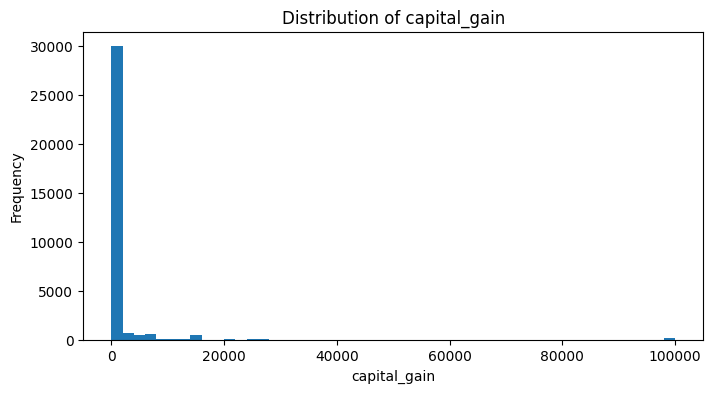

In [11]:
skewness = df_fe[num_cols].skew().sort_values(ascending=False)
display(skewness.to_frame("Skewness"))

# Plot the most strongly right-skewed original numerical feature.
skewed_feature = skewness.abs().idxmax()
print("Most skewed numerical feature:", skewed_feature)

plt.figure(figsize=(8, 4))
plt.hist(df_fe[skewed_feature], bins=50)
plt.title(f"Distribution of {skewed_feature}")
plt.xlabel(skewed_feature)
plt.ylabel("Frequency")
plt.show()


## 8. Log transformation

For a non-negative and strongly right-skewed variable, a common transformation is:

**log(1 + x)**

The `+1` allows zero values to be included. The logarithm compresses very large values more strongly than small values, which can reduce the effect of a long right tail.

I will apply this to `capital_gain`, which is a sensible choice because it is non-negative and typically contains many zeros with a smaller number of large values.


Skewness before log transformation: 11.9538
Skewness after log transformation: 3.0961


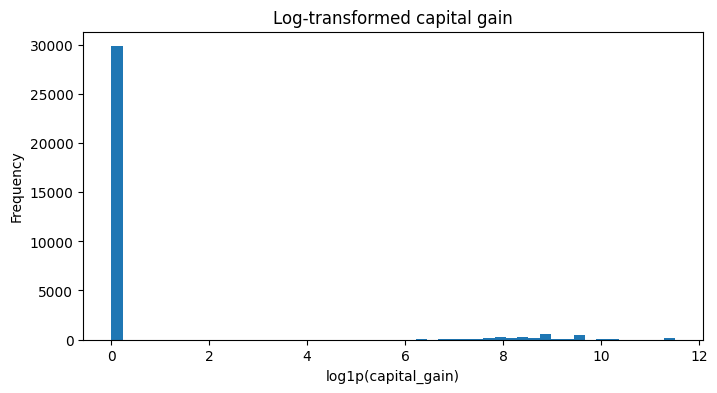

In [12]:
df_fe["capital_gain_log"] = np.log1p(df_fe["capital_gain"])

print("Skewness before log transformation:",
      round(df_fe["capital_gain"].skew(), 4))
print("Skewness after log transformation:",
      round(df_fe["capital_gain_log"].skew(), 4))

fig = plt.figure(figsize=(8, 4))
plt.hist(df_fe["capital_gain_log"], bins=50)
plt.title("Log-transformed capital gain")
plt.xlabel("log1p(capital_gain)")
plt.ylabel("Frequency")
plt.show()


## 9. Manual calculation examples

The assignment does not explicitly require hand-calculated answers; the scaling and transformation steps can be performed in Python. However, the formulas can be demonstrated manually to show what the code is doing.

### Standard Scaling

For one observation:

**z = (x - mean) / standard deviation**

For example, if a value were 50, the mean were 40, and the standard deviation were 5:

**z = (50 - 40) / 5 = 2**

### Min-Max Scaling

If a value were 50, the minimum were 10, and the maximum were 90:

**x_scaled = (50 - 10) / (90 - 10) = 40 / 80 = 0.5**

### Log transformation

For a capital gain of 2,000:

**log(1 + 2000) = log(2001)**

Python calculates these values directly, so there is no separate manual calculation that needs to be submitted unless the instructor specifically asks for handwritten working.


In [13]:
# Show the formulas numerically using the actual first row of age.
sample_col = "age"
x = df_fe.loc[0, sample_col]
mean_x = df_fe[sample_col].mean()
std_x = df_fe[sample_col].std()
min_x = df_fe[sample_col].min()
max_x = df_fe[sample_col].max()

manual_standard = (x - mean_x) / std_x
manual_minmax = (x - min_x) / (max_x - min_x)

print(f"Example column: {sample_col}")
print(f"x = {x}")
print(f"mean = {mean_x:.4f}")
print(f"std = {std_x:.4f}")
print(f"Manual standard scaling = {manual_standard:.4f}")
print(f"Manual min-max scaling = {manual_minmax:.4f}")
print(f"Manual log1p for capital_gain row 0 = {np.log1p(df_fe.loc[0, 'capital_gain']):.4f}")


Example column: age
x = 39
mean = 38.5816
std = 13.6404
Manual standard scaling = 0.0307
Manual min-max scaling = 0.3014
Manual log1p for capital_gain row 0 = 7.6848


## 10. Isolation Forest for unusual observations

Isolation Forest is an unsupervised anomaly-detection method. It isolates observations by randomly splitting the data; observations that are easier to isolate are more likely to be unusual.

I will use the numerical features for an exploratory anomaly check. This is not the same as saying that every detected row is wrong. An unusual observation may be a legitimate census observation, so I treat this step as a diagnostic rather than automatically deleting those records.


In [14]:
iso_features = df_fe[num_cols + [
    "capital_net",
    "hours_age_ratio",
    "has_capital_activity",
    "capital_gain_log"
]].copy()

# Isolation Forest is sensitive to scale, so standardize the inputs first.
iso_scaler = StandardScaler()
iso_X = iso_scaler.fit_transform(iso_features)

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

iso_labels = iso_model.fit_predict(iso_X)
df_fe["isolation_forest_flag"] = iso_labels

print("Isolation Forest result:")
print(df_fe["isolation_forest_flag"].value_counts())

print("\nFlagged percentage:",
      round((df_fe["isolation_forest_flag"] == -1).mean() * 100, 2), "%")

display(df_fe[df_fe["isolation_forest_flag"] == -1].head())


Isolation Forest result:
isolation_forest_flag
 1    32235
-1      326
Name: count, dtype: int64

Flagged percentage: 1.0 %


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_net,hours_age_ratio,has_capital_activity,capital_gain_log,isolation_forest_flag
106,17,?,304873,10th,6,Never-married,?,Own-child,White,Female,34095,0,32,United-States,<=50K,34095,1.882353,1,10.436935,-1
157,71,Self-emp-not-inc,494223,Some-college,10,Separated,Sales,Unmarried,Black,Male,0,1816,2,United-States,<=50K,-1816,0.028169,1,0.000000,-1
520,38,Self-emp-inc,99146,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,15024,0,80,United-States,>50K,15024,2.105263,1,9.617471,-1
534,67,Private,231559,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,20051,0,48,United-States,>50K,20051,0.716418,1,9.906084,-1
704,46,Private,295566,Doctorate,16,Divorced,Prof-specialty,Unmarried,White,Female,25236,0,65,United-States,>50K,25236,1.413043,1,10.136066,-1


## 11. Predictive Power Score (PPS) analysis

PPS measures how well one variable can predict another using a model-based score. Unlike correlation, PPS can detect non-linear relationships and is directional.

The assignment mentions PPS score analysis, so I include it as an exploratory feature-selection step.

The `ppscore` package may not be installed in every notebook environment. The following cell attempts to use it and gives an installation command if needed.


In [15]:
# Try to import PPS. If it is unavailable, the next line explains how to install it.
try:
    import ppscore as pps
    print("ppscore is available.")
except ImportError:
    pps = None
    print("ppscore is not installed.")
    print("If needed, run: %pip install ppscore")


ppscore is not installed.
If needed, run: %pip install ppscore


In [16]:
if pps is not None:
    # PPS works with the original categorical/numerical columns.
    pps_input = df_fe[num_cols + cat_cols + [
        "capital_net",
        "hours_age_ratio",
        "has_capital_activity",
        "capital_gain_log"
    ]].copy()

    # Convert categoricals to strings to keep their category nature explicit.
    for c in pps_input.select_dtypes(exclude=np.number).columns:
        pps_input[c] = pps_input[c].astype(str)

    pps_matrix = pps.matrix(pps_input)

    # Show the strongest non-self relationships.
    pps_results = pps_matrix[
        pps_matrix["x"] != pps_matrix["y"]
    ].sort_values("ppscore", ascending=False)

    display(pps_results[[
        "x", "y", "ppscore", "model_score"
    ]].head(20))
else:
    print("Run the previous installation command if PPS results are required in this environment.")


Run the previous installation command if PPS results are required in this environment.


## 12. Final preprocessing dataset

For a real model, I would normally build the final matrix using a preprocessing pipeline so that transformations learned from the training data are not accidentally applied using the whole dataset. For this assignment, I show a clear final encoded dataset following the requested encoding rules.

The target `income` is converted to a simple binary value:
- `<=50K` → 0
- `>50K` → 1


In [17]:
# Build final feature matrix.
# Original categorical columns are replaced by their requested encodings.
final_numeric = df_fe[num_cols + [
    "capital_net",
    "hours_age_ratio",
    "has_capital_activity",
    "capital_gain_log"
]].copy()

final_features = pd.concat(
    [final_numeric.reset_index(drop=True),
     one_hot_df.reset_index(drop=True),
     label_encoded_df.reset_index(drop=True)],
    axis=1
)

# Encode target.
y = (df_fe["income"].astype(str).str.strip() == ">50K").astype(int)

print("Final feature matrix shape:", final_features.shape)
print("Target shape:", y.shape)

display(final_features.head())
display(y.head())


Final feature matrix shape: (32561, 21)
Target shape: (32561,)


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,capital_net,hours_age_ratio,has_capital_activity,capital_gain_log,...,sex_ Male,income_ <=50K,income_ >50K,workclass,education,marital_status,occupation,relationship,race,native_country
0,39,77516,13,2174,0,40,2174,1.025641,1,7.684784,...,1,1,0,7,9,4,1,1,4,39
1,50,83311,13,0,0,13,0,0.260000,0,0.000000,...,1,1,0,6,9,2,4,0,4,39
2,38,215646,9,0,0,40,0,1.052632,0,0.000000,...,1,1,0,4,11,0,6,1,4,39
3,53,234721,7,0,0,40,0,0.754717,0,0.000000,...,1,1,0,4,1,2,6,0,2,39
4,28,338409,13,0,0,40,0,1.428571,0,0.000000,...,0,1,0,4,9,2,10,5,2,5


,income
0,0
1,0
2,0
3,0
4,0


## 13. Final observations and conclusion

- Missing values were identified after converting `?` to `NaN`, then imputed using median for numerical variables and mode for categorical variables.
- Standard Scaling and Min-Max Scaling were both demonstrated. Standard Scaling centers the data, while Min-Max Scaling places values into a bounded range.
- Categorical variables with fewer than 5 categories were one-hot encoded, while higher-cardinality categorical variables were label encoded as requested.
- Three engineered features were added: `capital_net`, `hours_age_ratio`, and `has_capital_activity`.
- `capital_gain` was log-transformed using `log1p` because of its strong right-skew and zero-heavy distribution.
- Isolation Forest was used as an exploratory method for identifying unusual numerical observations.
- PPS was included as a model-based way to investigate predictive relationships between variables.
- The final matrix is now in a form that can be passed to a machine-learning model after applying the appropriate train/test split and model-specific preprocessing pipeline.
